Retreiving and extracting variable 'absorbing_aerosol_index' from collection 'COPERNICUS/S5P/NRTI/L3_AER_AI' ...
Collection/variable: COPERNICUS/S5P/NRTI/L3_AER_AI/absorbing_aerosol_index


,dte,nrb,mkn
count,2153,2106.000000,2021.000000
mean,2021-06-20 00:00:00,-0.824434,-0.788493
min,2018-07-10 00:00:00,-3.295188,-4.209562
25%,2019-12-30 00:00:00,-1.399714,-1.387125
50%,2021-06-20 00:00:00,-0.856082,-0.694988
75%,2022-12-10 00:00:00,-0.260008,-0.105609
max,2024-05-31 00:00:00,1.768988,2.954804
std,NaN,0.796428,0.944359


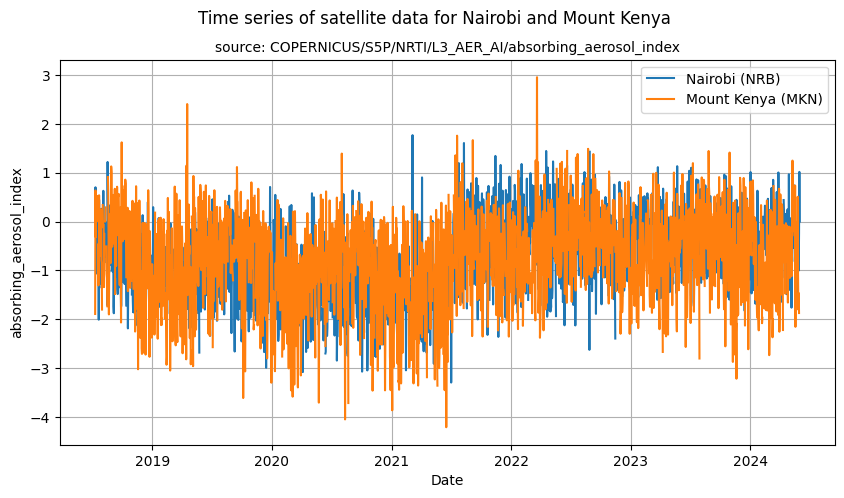

Retreiving and extracting variable 'absorbing_aerosol_index' from collection 'COPERNICUS/S5P/OFFL/L3_AER_AI' ...
Collection/variable: COPERNICUS/S5P/OFFL/L3_AER_AI/absorbing_aerosol_index


,dte,nrb,mkn
count,2153,2135.000000,2051.000000
mean,2021-06-20 00:00:00,-0.826476,-0.802240
min,2018-07-10 00:00:00,-3.129156,-4.209580
25%,2019-12-30 00:00:00,-1.401527,-1.408337
50%,2021-06-20 00:00:00,-0.853947,-0.706638
75%,2022-12-10 00:00:00,-0.276420,-0.122546
max,2024-05-31 00:00:00,1.780206,2.756760
std,NaN,0.794446,0.949289


<Figure size 640x480 with 0 Axes>

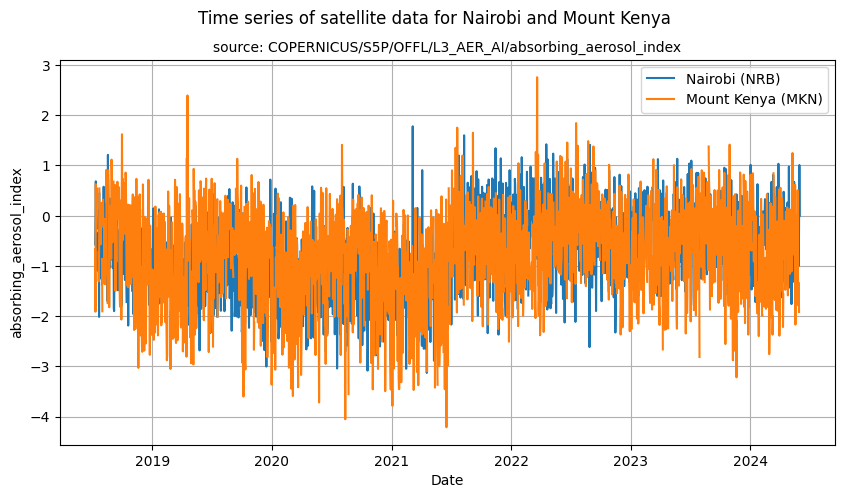

Retreiving and extracting variable 'Optical_Depth_047' from collection 'MODIS/061/MCD19A2_GRANULES' ...
Collection/variable: MODIS/061/MCD19A2_GRANULES/Optical_Depth_047


,dte,nrb,mkn
count,9283,2375.000000,1844.000000
mean,2011-09-16 00:00:00,237.458316,168.201057
min,1999-01-01 00:00:00,0.000000,0.000000
25%,2005-05-09 12:00:00,139.750000,0.000000
50%,2011-09-16 00:00:00,241.500000,159.250000
75%,2018-01-22 12:00:00,342.250000,249.125000
max,2024-05-31 00:00:00,1563.000000,5136.000000
std,NaN,163.198927,178.681866


<Figure size 640x480 with 0 Axes>

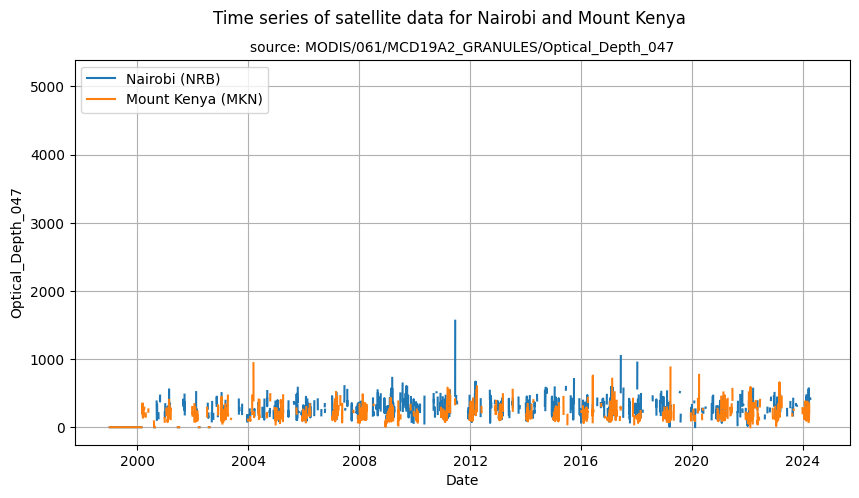

Retreiving and extracting variable 'Optical_Depth_055' from collection 'MODIS/061/MCD19A2_GRANULES' ...
Collection/variable: MODIS/061/MCD19A2_GRANULES/Optical_Depth_055


,dte,nrb,mkn
count,9283,2375.000000,1844.000000
mean,2011-09-16 00:00:00,172.327053,121.660385
min,1999-01-01 00:00:00,0.000000,0.000000
25%,2005-05-09 12:00:00,99.750000,0.000000
50%,2011-09-16 00:00:00,174.000000,114.000000
75%,2018-01-22 12:00:00,249.000000,179.500000
max,2024-05-31 00:00:00,1215.000000,4061.000000
std,NaN,119.962961,135.209760


<Figure size 640x480 with 0 Axes>

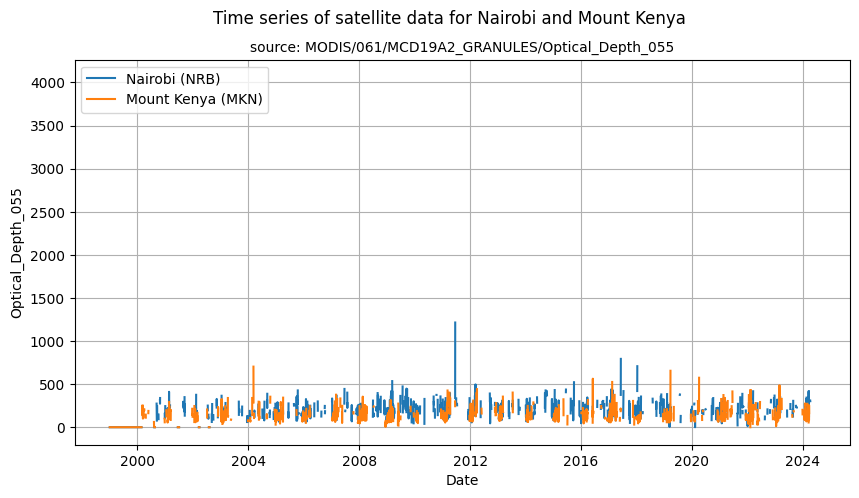

Retreiving and extracting variable 'AOD_Uncertainty' from collection 'MODIS/061/MCD19A2_GRANULES' ...
Collection/variable: MODIS/061/MCD19A2_GRANULES/AOD_Uncertainty


,dte,nrb,mkn
count,9283,8866.000000,8475.000000
mean,2011-09-16 00:00:00,283.212873,251.155664
min,1999-01-01 00:00:00,0.000000,0.000000
25%,2005-05-09 12:00:00,181.000000,164.000000
50%,2011-09-16 00:00:00,257.000000,231.500000
75%,2018-01-22 12:00:00,393.000000,350.000000
max,2024-05-31 00:00:00,866.000000,617.000000
std,NaN,138.705205,118.076839


<Figure size 640x480 with 0 Axes>

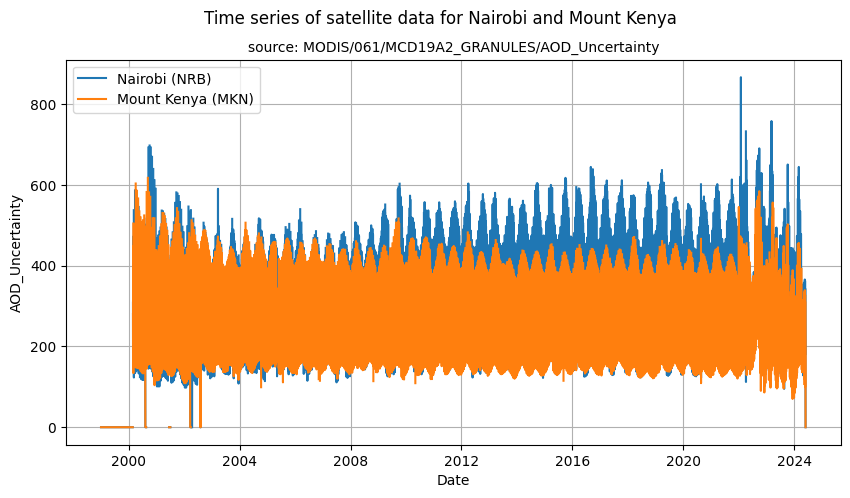

Retreiving and extracting variable 'Column_WV' from collection 'MODIS/061/MCD19A2_GRANULES' ...


In [27]:
# Install the Earth Engine Python library
# !pip install earthengine-api
# !pip install folium

import os
import ee
# import folium
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate. This should only be necessary once. I ran the script in debug mode first, and authentication involved a visit of an external web site, generation of a token, and copy/paste of this in VS Code.
# ee.Authenticate()

# Specify data sources
collections = {
    'COPERNICUS/S5P/NRTI/L3_AER_AI': {
        'start': '2018-07-10',
        # 'start': '2024-05-10',
        'end': '2024-05-31', 
        'variables': ['absorbing_aerosol_index', 
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_NRTI_L3_AER_AI'
    },
    'COPERNICUS/S5P/OFFL/L3_AER_AI': {
        'start': '2018-07-10',
        # 'start': '2024-05-10',
        'end': '2024-05-31', 
        'variables': ['absorbing_aerosol_index', 
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_AER_AI'
    },
    'MODIS/061/MCD19A2_GRANULES': {
        # 'start': '1999-01-01',
        'start': '2019-01-01',
        'end': '2024-05-31',
        'variables': ['Optical_Depth_047', 
                      'Optical_Depth_055', 
                      'AOD_Uncertainty', 
                      'Column_WV', 
                      'AOD_QA', 
                      'Injection_Height',  
                    #   'cosSZA',
                    #   'cosVZA',
                    #   'RelAZ',
                    #   'Scattering_Angle',
                    #   'Glint_Angle',
                      'FineModeFraction',
                      'AngstromExp_470-780',    # only over the ocean?
                      ],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES'
    },
    'MODIS/061/MCD64A1': {
        'start': '1999-01-01',
        # 'start': '2024-05-10',
        'end': '2024-05-31',
        'variables': ['BurnDate', 'Uncertainty', 'QA', 'FirstDay', 'LastDay'],
        'description': 'https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD64A1'
    },
}

# Initialize the Earth Engine module.
ee.Initialize()

# Define a region of interest (Nairobi and Mount Kenya)
nrb = ee.Geometry.Point([36.7592, -1.3017])
mkn = ee.Geometry.Point([37.2972, -0.0622])

# get mean values for a point
def get_mean_value(point, start_date, end_date) -> dict:
    try:
        result = ee_collection.filterDate(start_date, end_date).mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=1000
        ).getInfo()
        return result
    except Exception as err:
        print(f"{start_date}, {end_date}: {err}")
        return dict()

# plot data
def plot_data(df, target, collection, variable, save=True):
    plt.figure(figsize=(10, 5))
    plt.plot(df['dte'], df['nrb'], label='Nairobi (NRB)')
    plt.plot(df['dte'], df['mkn'], label='Mount Kenya (MKN)')
    plt.xlabel('Date')
    plt.ylabel(variable)
    plt.suptitle("Time series of satellite data for Nairobi and Mount Kenya")
    plt.title(f"source: {collection}/{variable}", size=10)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.savefig(os.path.join(target, f"{variable}.png"))


for collection in collections.keys():
    for variable in collections[collection]['variables']:
        print(f"Retrieving and extracting variable '{variable}' from collection '{collection}' ...")
        start = collections[collection]['start']
        end = collections[collection]['end']
        ee_collection = ee.ImageCollection(collection).select(variable).filterDate(start, end)
        target = os.path.join('data/level3/', collection.lower())
        os.makedirs(target, exist_ok=True)

        # get time series data for individual variable
        dates = pd.date_range(start, end, freq='D')
        nrb_data = list()
        mkn_data = list()
        for date in dates:
            try:
                nrb_data.append(get_mean_value(nrb, str(date.date()), str((date + pd.DateOffset(days=1)).date())).get(variable, float()))
            except Exception as err:
                print(f"NRB: {date}: {err}")
                pass
            try:
                mkn_data.append(get_mean_value(mkn, str(date.date()), str((date + pd.DateOffset(days=1)).date())).get(variable, float()))
            except Exception as err:
                print(f"MKN: {date}: {err}")
                pass

        # Create a DataFrame and save data
        df = pd.DataFrame({
            'dte': dates,
            'nrb': nrb_data,
            'mkn': mkn_data
        })
        df.to_parquet(os.path.join(target, f"{variable}.parquet"))
        print(f"Collection/variable: {collection}/{variable}")
        display(df.describe())

        # plot data
        plot_data(df, target, collection, variable)


In [25]:
# modis_image = ee.ImageCollection('MODIS/061/MCD64A1').first()
# modis_bands = modis_image.bandNames().getInfo()
# modis_bands


['BurnDate', 'Uncertainty', 'QA', 'FirstDay', 'LastDay']

In [17]:
s5p_image = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_AER_AI').first()
s5p_bands = s5p_image.bandNames().getInfo()
s5p_bands

['absorbing_aerosol_index',
 'sensor_altitude',
 'sensor_azimuth_angle',
 'sensor_zenith_angle',
 'solar_azimuth_angle',
 'solar_zenith_angle']

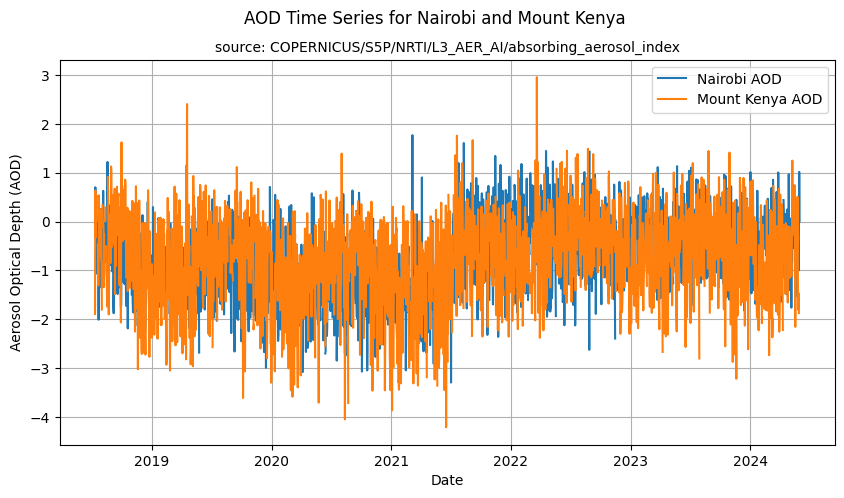

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df['dte'], df['nrb'], label='Nairobi (NRB)')
plt.plot(df['dte'], df['mkn'], label='Mount Kenya (MKN)')
plt.xlabel('Date')
plt.ylabel('Aerosol Optical Depth (AOD)')
plt.suptitle('AOD Time Series for Nairobi and Mount Kenya')
plt.title(f"source: {collection}/{variable}", size=10)
plt.legend()
plt.grid(True)
plt.show()
plt.savefig(os.path.join(target, f"{variable}.png"))


In [ ]:
modis_aod = ee.ImageCollection('MODIS/006/MOD04_L2').select('Optical_Depth_Land_And_Ocean').filterDate(start_date, end_date)
